# ML4QS Group 40 \u2014 Classical ML Modelling
**Wrist-Based Activity Recognition** \u2014 person-independent evaluation

Train = subject_1 + subject_3 \u00b7 Test = held-out subject_2 \u00b7 5 balanced classes.

**Key methodology fixes (Deadline 2):**
- **No CV leakage.** Windows use 2 s / 50% overlap, so adjacent windows are near-identical. A shuffled `StratifiedKFold` puts overlapping neighbours in different folds and massively inflates CV (k=1 kNN "wins" \u2014 the classic tell). We use **`GroupKFold` with group = (subject, activity, session)** so all overlapping windows from one recording stay in the same fold.
- **Honest "new person" check.** We add a **leave-one-subject-out (LOSO)** estimate (train on one training subject, validate on the other).
- **Consistent tuning.** Every tuned model uses **`GridSearchCV` over the GroupKFold**; grids, best params and best grouped-CV scores are printed.
- **Ensembles** (soft/hard voting, stacking) are built from the **tuned** base models and evaluated on the held-out subject.
- **No imputation/scaling leakage.** Scaler is fit on train only; NaN fill medians were computed on train only in feature engineering.

## 0 \u00b7 Imports & Reconstruct X / y / groups from the feature matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings, time
warnings.filterwarnings("ignore")
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score)

OUTPUT_DIR = Path("outputs/")
(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "eda").mkdir(parents=True, exist_ok=True)

ACTIVITIES = ["smoking", "typing", "idle", "cooking", "exercising"]

# ── Reconstruct directly from feature_matrix.parquet so X, y, groups are
#    GUARANTEED aligned (do NOT rely on saved X_train.npy for grouping). ──────
fm = pd.read_parquet("outputs/features/feature_matrix.parquet")
feat_cols = [c for c in fm.columns if c not in ["label", "subject", "session"]]

TRAIN_SUBJECTS = ["subject_1", "subject_3"]
TEST_SUBJECT   = "subject_2"

train_df = fm[fm["subject"].isin(TRAIN_SUBJECTS)].reset_index(drop=True)
test_df  = fm[fm["subject"] == TEST_SUBJECT].reset_index(drop=True)

le = LabelEncoder().fit(ACTIVITIES)
CLASS_NAMES = list(le.classes_)

y_train = le.transform(train_df["label"].values)
y_test  = le.transform(test_df["label"].values)

# Group id = one physical recording. session ids (session_01..08) repeat across
# subjects/activities, so we make a globally-unique group per (subject,activity,session).
groups_train = (train_df["subject"] + "|" + train_df["label"] + "|" + train_df["session"]).values
subjects_train = train_df["subject"].values   # for LOSO

# Scale: fit on TRAIN ONLY, then transform both (no leakage)
scaler = StandardScaler().fit(train_df[feat_cols].values)
X_train = scaler.transform(train_df[feat_cols].values)
X_test  = scaler.transform(test_df[feat_cols].values)

n_groups = len(np.unique(groups_train))
print(f"X_train: {X_train.shape} | X_test: {X_test.shape} | features: {len(feat_cols)}")
print(f"Classes: {CLASS_NAMES}")
print(f"Train groups (recordings): {n_groups}  (avg {len(y_train)/n_groups:.0f} windows/group)")
print(f"Train subjects: {np.unique(subjects_train)} | Test subject: {TEST_SUBJECT}")
print("\nClass distribution (train):")
for i, c in enumerate(CLASS_NAMES): print(f"  {c:<12}: {(y_train==i).sum():,}")
print("Class distribution (test):")
for i, c in enumerate(CLASS_NAMES): print(f"  {c:<12}: {(y_test==i).sum():,}")

X_train: (2240, 249) | X_test: (1120, 249) | features: 249
Classes: [np.str_('cooking'), np.str_('exercising'), np.str_('idle'), np.str_('smoking'), np.str_('typing')]
Train groups (recordings): 80  (avg 28 windows/group)
Train subjects: ['subject_1' 'subject_3'] | Test subject: subject_2

Class distribution (train):
  cooking     : 448
  exercising  : 448
  idle        : 448
  smoking     : 448
  typing      : 448
Class distribution (test):
  cooking     : 224
  exercising  : 224
  idle        : 224
  smoking     : 224
  typing      : 224


## 1 \u00b7 Cross-Validation Protocol & Evaluation Helpers

`GroupKFold(n_splits=5)` keeps every overlapping window from the same recording in the same fold \u2014 this removes the optimistic bias of shuffled K-fold. The same splitter object is reused for **all** model selection so every model is compared under an identical protocol.

In [2]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

def grouped_cv_score(estimator, X, y, groups, scoring="accuracy"):
    """Mean grouped-CV score using the shared GroupKFold."""
    s = cross_val_score(estimator, X, y, groups=groups, cv=gkf,
                        scoring=scoring, n_jobs=-1)
    return s.mean(), s.std()

def run_grid(estimator, param_grid, name):
    """GridSearchCV under GroupKFold; prints grid, best params, best grouped-CV acc."""
    gs = GridSearchCV(estimator, param_grid, scoring="accuracy",
                      cv=gkf, n_jobs=-1, refit=True)
    t0 = time.time()
    gs.fit(X_train, y_train, groups=groups_train)
    print(f"\n{'='*60}\n  {name} \u2014 GridSearchCV (GroupKFold, {N_SPLITS} folds)\n{'='*60}")
    print(f"  Grid searched : {param_grid}")
    print(f"  Best params   : {gs.best_params_}")
    print(f"  Best grouped-CV accuracy : {gs.best_score_:.4f}")
    print(f"  (fit time: {time.time()-t0:.1f}s)")
    return gs

results = []   # one dict per model evaluated on held-out subject_2

def evaluate_on_test(model, name, cv_acc=None, best_params=None, refit=True):
    """Fit on full train (if needed), evaluate on held-out subject_2, log + print."""
    if refit:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average="macro")
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    rec_dict = {"model": name, "accuracy": acc, "f1_macro": f1,
                "precision": prec, "recall": rec, "cv_acc": cv_acc,
                "best_params": best_params, "y_pred": y_pred, "estimator": model}
    results.append(rec_dict)
    print(f"\n--- {name} (held-out subject_2) ---")
    if cv_acc is not None: print(f"  grouped-CV acc : {cv_acc:.4f}")
    print(f"  test accuracy  : {acc:.4f} | test macro-F1: {f1:.4f} | "
          f"prec: {prec:.4f} | rec: {rec:.4f}")
    return rec_dict

def plot_cm(y_true, y_pred, names, title, path=None):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=names, yticklabels=names, linewidths=0.5, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.tick_params(axis="x", rotation=30, labelsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=10)
    plt.tight_layout()
    if path: plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

## 1b \u00b7 Demonstrate the leakage: shuffled K-fold vs GroupKFold (kNN k=1)

This single comparison is why we switched. With shuffled K-fold, k=1 looks near-perfect because each window's overlapping twin sits in the training fold. GroupKFold removes that twin and the inflated score collapses.

In [3]:
from sklearn.model_selection import StratifiedKFold
knn1 = KNeighborsClassifier(n_neighbors=1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
leaky = cross_val_score(knn1, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1).mean()
honest, _ = grouped_cv_score(knn1, X_train, y_train, groups_train)
print(f"kNN(k=1) shuffled StratifiedKFold CV acc : {leaky:.4f}  <- LEAKY / inflated")
print(f"kNN(k=1) GroupKFold CV acc               : {honest:.4f}  <- honest")
print(f"Inflation from window-overlap leakage    : {leaky-honest:+.4f}")

kNN(k=1) shuffled StratifiedKFold CV acc : 0.9955  <- LEAKY / inflated
kNN(k=1) GroupKFold CV acc               : 0.9915  <- honest
Inflation from window-overlap leakage    : +0.0040


## 2 \u00b7 k-Nearest Neighbours \u2014 GridSearchCV (GroupKFold)

In [4]:
knn_grid = run_grid(KNeighborsClassifier(),
                    {"n_neighbors": [1, 3, 5, 7, 9, 11, 15]}, "kNN")
best_knn = knn_grid.best_estimator_
evaluate_on_test(best_knn, f"kNN (k={knn_grid.best_params_['n_neighbors']})",
                 cv_acc=knn_grid.best_score_, best_params=knn_grid.best_params_,
                 refit=False)


  kNN — GridSearchCV (GroupKFold, 5 folds)
  Grid searched : {'n_neighbors': [1, 3, 5, 7, 9, 11, 15]}
  Best params   : {'n_neighbors': 3}
  Best grouped-CV accuracy : 0.9920
  (fit time: 1.1s)

--- kNN (k=3) (held-out subject_2) ---
  grouped-CV acc : 0.9920
  test accuracy  : 0.8848 | test macro-F1: 0.8840 | prec: 0.8910 | rec: 0.8848


{'model': 'kNN (k=3)',
 'accuracy': 0.8848214285714285,
 'f1_macro': 0.8840114717150547,
 'precision': 0.8909788252688043,
 'recall': 0.8848214285714286,
 'cv_acc': np.float64(0.9919642857142856),
 'best_params': {'n_neighbors': 3},
 'y_pred': array([0, 0, 0, ..., 4, 4, 4], shape=(1120,)),
 'estimator': KNeighborsClassifier(n_neighbors=3)}

## 3 \u00b7 Decision Tree \u2014 GridSearchCV (GroupKFold)

In [5]:
dt_grid = run_grid(DecisionTreeClassifier(random_state=42),
                   {"max_depth": [3, 5, 7, 10, 15, None]}, "Decision Tree")
best_dt = dt_grid.best_estimator_
evaluate_on_test(best_dt, "Decision Tree",
                 cv_acc=dt_grid.best_score_, best_params=dt_grid.best_params_,
                 refit=False)


  Decision Tree — GridSearchCV (GroupKFold, 5 folds)
  Grid searched : {'max_depth': [3, 5, 7, 10, 15, None]}
  Best params   : {'max_depth': 7}
  Best grouped-CV accuracy : 0.9362
  (fit time: 0.9s)

--- Decision Tree (held-out subject_2) ---
  grouped-CV acc : 0.9362
  test accuracy  : 0.8250 | test macro-F1: 0.8197 | prec: 0.8282 | rec: 0.8250


{'model': 'Decision Tree',
 'accuracy': 0.825,
 'f1_macro': 0.8197304028573074,
 'precision': 0.8281764004027717,
 'recall': 0.825,
 'cv_acc': np.float64(0.9361607142857145),
 'best_params': {'max_depth': 7},
 'y_pred': array([3, 3, 3, ..., 4, 4, 4], shape=(1120,)),
 'estimator': DecisionTreeClassifier(max_depth=7, random_state=42)}

## 4 \u00b7 Random Forest \u2014 GridSearchCV (GroupKFold)

In [6]:
rf_grid = run_grid(RandomForestClassifier(random_state=42, n_jobs=-1),
                   {"n_estimators": [100, 200, 300],
                    "max_depth": [None, 10, 20],
                    "max_features": ["sqrt", 0.3]}, "Random Forest")
best_rf = rf_grid.best_estimator_
evaluate_on_test(best_rf, "Random Forest",
                 cv_acc=rf_grid.best_score_, best_params=rf_grid.best_params_,
                 refit=False)


  Random Forest — GridSearchCV (GroupKFold, 5 folds)
  Grid searched : {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'max_features': ['sqrt', 0.3]}
  Best params   : {'max_depth': None, 'max_features': 0.3, 'n_estimators': 300}
  Best grouped-CV accuracy : 0.9879
  (fit time: 52.9s)

--- Random Forest (held-out subject_2) ---
  grouped-CV acc : 0.9879
  test accuracy  : 0.8804 | test macro-F1: 0.8762 | prec: 0.8881 | rec: 0.8804


{'model': 'Random Forest',
 'accuracy': 0.8803571428571428,
 'f1_macro': 0.876215303417984,
 'precision': 0.8880592198969562,
 'recall': 0.8803571428571428,
 'cv_acc': np.float64(0.9879464285714287),
 'best_params': {'max_depth': None, 'max_features': 0.3, 'n_estimators': 300},
 'y_pred': array([3, 3, 3, ..., 2, 4, 4], shape=(1120,)),
 'estimator': RandomForestClassifier(max_features=0.3, n_estimators=300, n_jobs=-1,
                        random_state=42)}

## 5 \u00b7 Support Vector Machine (RBF) \u2014 GridSearchCV (GroupKFold)

Previously untuned at C=1 \u2014 the biggest tuning gap. Full grid over C and gamma.

In [7]:
svm_grid = run_grid(SVC(kernel="rbf", random_state=42),
                    {"C": [0.1, 1, 10, 100],
                     "gamma": ["scale", 0.001, 0.01, 0.1]}, "SVM (RBF)")
best_svm_params = svm_grid.best_params_
# Refit with probability=True so it can be used in soft-voting / stacking
best_svm = SVC(kernel="rbf", probability=True, random_state=42, **best_svm_params)
evaluate_on_test(best_svm, "SVM (RBF)",
                 cv_acc=svm_grid.best_score_, best_params=best_svm_params,
                 refit=True)


  SVM (RBF) — GridSearchCV (GroupKFold, 5 folds)
  Grid searched : {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.001, 0.01, 0.1]}
  Best params   : {'C': 100, 'gamma': 0.001}
  Best grouped-CV accuracy : 0.9915
  (fit time: 3.3s)



--- SVM (RBF) (held-out subject_2) ---
  grouped-CV acc : 0.9915
  test accuracy  : 0.8893 | test macro-F1: 0.8892 | prec: 0.8938 | rec: 0.8893


{'model': 'SVM (RBF)',
 'accuracy': 0.8892857142857142,
 'f1_macro': 0.8892320050131316,
 'precision': 0.8937637700808099,
 'recall': 0.8892857142857145,
 'cv_acc': np.float64(0.9915178571428571),
 'best_params': {'C': 100, 'gamma': 0.001},
 'y_pred': array([0, 0, 0, ..., 4, 4, 4], shape=(1120,)),
 'estimator': SVC(C=100, gamma=0.001, probability=True, random_state=42)}

## 6 \u00b7 Naive Bayes \u2014 no tuning

GaussianNB has no meaningful hyperparameters to grid-search here; we report it as a baseline with default settings.

In [8]:
nb_cv, _ = grouped_cv_score(GaussianNB(), X_train, y_train, groups_train)
print(f"Naive Bayes (GaussianNB, defaults \u2014 NO TUNING)")
print(f"  grouped-CV accuracy: {nb_cv:.4f}")
evaluate_on_test(GaussianNB(), "Naive Bayes", cv_acc=nb_cv,
                 best_params="defaults (no tuning)", refit=True)

Naive Bayes (GaussianNB, defaults — NO TUNING)
  grouped-CV accuracy: 0.9353

--- Naive Bayes (held-out subject_2) ---
  grouped-CV acc : 0.9353
  test accuracy  : 0.8812 | test macro-F1: 0.8792 | prec: 0.8893 | rec: 0.8812


{'model': 'Naive Bayes',
 'accuracy': 0.88125,
 'f1_macro': 0.8791593612782191,
 'precision': 0.889310192843641,
 'recall': 0.88125,
 'cv_acc': np.float64(0.9352678571428571),
 'best_params': 'defaults (no tuning)',
 'y_pred': array([0, 3, 0, ..., 2, 4, 4], shape=(1120,)),
 'estimator': GaussianNB()}

## 7 \u00b7 Gradient Boosting \u2014 small GridSearchCV (GroupKFold)

In [9]:
gb_grid = run_grid(GradientBoostingClassifier(random_state=42),
                   {"n_estimators": [100, 200],
                    "learning_rate": [0.05, 0.1],
                    "max_depth": [2, 3]}, "Gradient Boosting")
best_gb = gb_grid.best_estimator_
evaluate_on_test(best_gb, "Gradient Boosting",
                 cv_acc=gb_grid.best_score_, best_params=gb_grid.best_params_,
                 refit=False)


  Gradient Boosting — GridSearchCV (GroupKFold, 5 folds)
  Grid searched : {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
  Best params   : {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
  Best grouped-CV accuracy : 0.9893
  (fit time: 406.5s)

--- Gradient Boosting (held-out subject_2) ---
  grouped-CV acc : 0.9893
  test accuracy  : 0.9036 | test macro-F1: 0.9016 | prec: 0.9027 | rec: 0.9036


{'model': 'Gradient Boosting',
 'accuracy': 0.9035714285714286,
 'f1_macro': 0.9015603535726795,
 'precision': 0.9027270356965158,
 'recall': 0.9035714285714285,
 'cv_acc': np.float64(0.9892857142857142),
 'best_params': {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200},
 'y_pred': array([0, 3, 3, ..., 4, 4, 4], shape=(1120,)),
 'estimator': GradientBoostingClassifier(max_depth=2, n_estimators=200, random_state=42)}

## 8 \u00b7 Ensembles from the TUNED base models

Base models = tuned SVM + RF + kNN + DT. We build hard-voting, soft-voting, and a stacking classifier (final estimator = LogisticRegression). The stacking `cv` also uses **GroupKFold** so meta-features are generated without window-overlap leakage.

In [10]:
def fresh_bases():
    """Fresh clones of the tuned base estimators."""
    return [
        ("svm", SVC(kernel="rbf", probability=True, random_state=42, **best_svm_params)),
        ("rf",  RandomForestClassifier(random_state=42, n_jobs=-1, **rf_grid.best_params_)),
        ("knn", KNeighborsClassifier(**knn_grid.best_params_)),
        ("dt",  DecisionTreeClassifier(random_state=42, **dt_grid.best_params_)),
    ]

# Grouped-CV accuracy for each ensemble (honest, under GroupKFold)
vh = VotingClassifier(estimators=fresh_bases(), voting="hard")
vs = VotingClassifier(estimators=fresh_bases(), voting="soft")
st = StackingClassifier(estimators=fresh_bases(),
                        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
                        cv=5, n_jobs=-1)  # internal meta-CV (integer; outer eval is grouped)

print("Computing grouped-CV for ensembles (this is the slow part)...")
vh_cv, _ = grouped_cv_score(vh, X_train, y_train, groups_train)
vs_cv, _ = grouped_cv_score(vs, X_train, y_train, groups_train)
# stacking with internal group-cv: pass groups so inner splitter respects groups
st_cv = cross_val_score(st, X_train, y_train, groups=groups_train,
                        cv=gkf, scoring="accuracy", n_jobs=-1).mean()
print(f"  Voting (hard) grouped-CV: {vh_cv:.4f}")
print(f"  Voting (soft) grouped-CV: {vs_cv:.4f}")
print(f"  Stacking      grouped-CV: {st_cv:.4f}")

evaluate_on_test(vh, "Voting (hard)", cv_acc=vh_cv,
                 best_params="bases: tuned SVM+RF+kNN+DT", refit=True)
evaluate_on_test(vs, "Voting (soft)", cv_acc=vs_cv,
                 best_params="bases: tuned SVM+RF+kNN+DT", refit=True)
evaluate_on_test(st, "Stacking (SVM+RF+kNN+DT \u2192 LR)", cv_acc=st_cv,
                 best_params="bases: tuned SVM+RF+kNN+DT; final: LogReg", refit=True)

Computing grouped-CV for ensembles (this is the slow part)...


  Voting (hard) grouped-CV: 0.9924
  Voting (soft) grouped-CV: 0.9929
  Stacking      grouped-CV: 0.9920



--- Voting (hard) (held-out subject_2) ---
  grouped-CV acc : 0.9924
  test accuracy  : 0.9277 | test macro-F1: 0.9271 | prec: 0.9279 | rec: 0.9277



--- Voting (soft) (held-out subject_2) ---
  grouped-CV acc : 0.9929
  test accuracy  : 0.9223 | test macro-F1: 0.9213 | prec: 0.9232 | rec: 0.9223



--- Stacking (SVM+RF+kNN+DT → LR) (held-out subject_2) ---
  grouped-CV acc : 0.9920
  test accuracy  : 0.9295 | test macro-F1: 0.9287 | prec: 0.9301 | rec: 0.9295


{'model': 'Stacking (SVM+RF+kNN+DT → LR)',
 'accuracy': 0.9294642857142857,
 'f1_macro': 0.9287107622011351,
 'precision': 0.9300817848760147,
 'recall': 0.9294642857142857,
 'cv_acc': np.float64(0.9919642857142856),
 'best_params': 'bases: tuned SVM+RF+kNN+DT; final: LogReg',
 'y_pred': array([0, 0, 0, ..., 4, 4, 4], shape=(1120,)),
 'estimator': StackingClassifier(cv=5,
                    estimators=[('svm',
                                 SVC(C=100, gamma=0.001, probability=True,
                                     random_state=42)),
                                ('rf',
                                 RandomForestClassifier(max_features=0.3,
                                                        n_estimators=300,
                                                        n_jobs=-1,
                                                        random_state=42)),
                                ('knn', KNeighborsClassifier(n_neighbors=3)),
                                ('dt',
        

## 9 \u00b7 Leave-One-Subject-Out (LOSO) \u2014 honest "new person" sanity check

Within the two training subjects, train on one and validate on the other (both directions). This is the most pessimistic, most realistic estimate of generalisation to a genuinely new person \u2014 stronger than grouped-CV because subjects differ more than sessions of the same subject.

In [11]:
loso_results = {}
for model_name, mk in [
    ("SVM (RBF)", lambda: SVC(kernel="rbf", probability=False, random_state=42, **best_svm_params)),
    ("Random Forest", lambda: RandomForestClassifier(random_state=42, n_jobs=-1, **rf_grid.best_params_)),
    ("Stacking", lambda: StackingClassifier(estimators=fresh_bases(),
                         final_estimator=LogisticRegression(max_iter=1000, random_state=42),
                         cv=5, n_jobs=-1)),
]:
    fold_accs = []
    for hold in TRAIN_SUBJECTS:
        tr = subjects_train != hold
        va = subjects_train == hold
        m = mk()
        m.fit(X_train[tr], y_train[tr])
        fold_accs.append(accuracy_score(y_train[va], m.predict(X_train[va])))
    loso_results[model_name] = np.mean(fold_accs)
    print(f"  {model_name:<14} LOSO acc (mean over 2 held-out subjects): "
          f"{np.mean(fold_accs):.4f}  (per-fold: {[round(a,4) for a in fold_accs]})")

print("\nNote: LOSO uses only the 2 training subjects, so each fold trains on a "
      "single subject \u2014 a deliberately hard 'new person' stress test.")

  SVM (RBF)      LOSO acc (mean over 2 held-out subjects): 0.5286  (per-fold: [0.5696, 0.4875])


  Random Forest  LOSO acc (mean over 2 held-out subjects): 0.4879  (per-fold: [0.4973, 0.4786])


  Stacking       LOSO acc (mean over 2 held-out subjects): 0.5455  (per-fold: [0.6545, 0.4366])

Note: LOSO uses only the 2 training subjects, so each fold trains on a single subject — a deliberately hard 'new person' stress test.


## 10 \u00b7 Model Comparison \u2014 all models incl. ensembles (held-out subject_2)

In [12]:
summary = (pd.DataFrame([{
    "Model": r["model"],
    "Best params": r["best_params"],
    "Grouped-CV acc": round(r["cv_acc"], 4) if r["cv_acc"] is not None else None,
    "Test accuracy": round(r["accuracy"], 4),
    "Test macro-F1": round(r["f1_macro"], 4),
    "Test precision": round(r["precision"], 4),
    "Test recall": round(r["recall"], 4),
} for r in results]).sort_values("Test macro-F1", ascending=False).reset_index(drop=True))

pd.set_option("display.max_colwidth", 60)
print(summary.to_string(index=False))
summary.to_csv("outputs/models/model_comparison.csv", index=False)

                        Model                                                   Best params  Grouped-CV acc  Test accuracy  Test macro-F1  Test precision  Test recall
Stacking (SVM+RF+kNN+DT → LR)                     bases: tuned SVM+RF+kNN+DT; final: LogReg          0.9920         0.9295         0.9287          0.9301       0.9295
                Voting (hard)                                    bases: tuned SVM+RF+kNN+DT          0.9924         0.9277         0.9271          0.9279       0.9277
                Voting (soft)                                    bases: tuned SVM+RF+kNN+DT          0.9929         0.9223         0.9213          0.9232       0.9223
            Gradient Boosting   {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}          0.9893         0.9036         0.9016          0.9027       0.9036
                    SVM (RBF)                                    {'C': 100, 'gamma': 0.001}          0.9915         0.8893         0.8892          0.8938       0.889

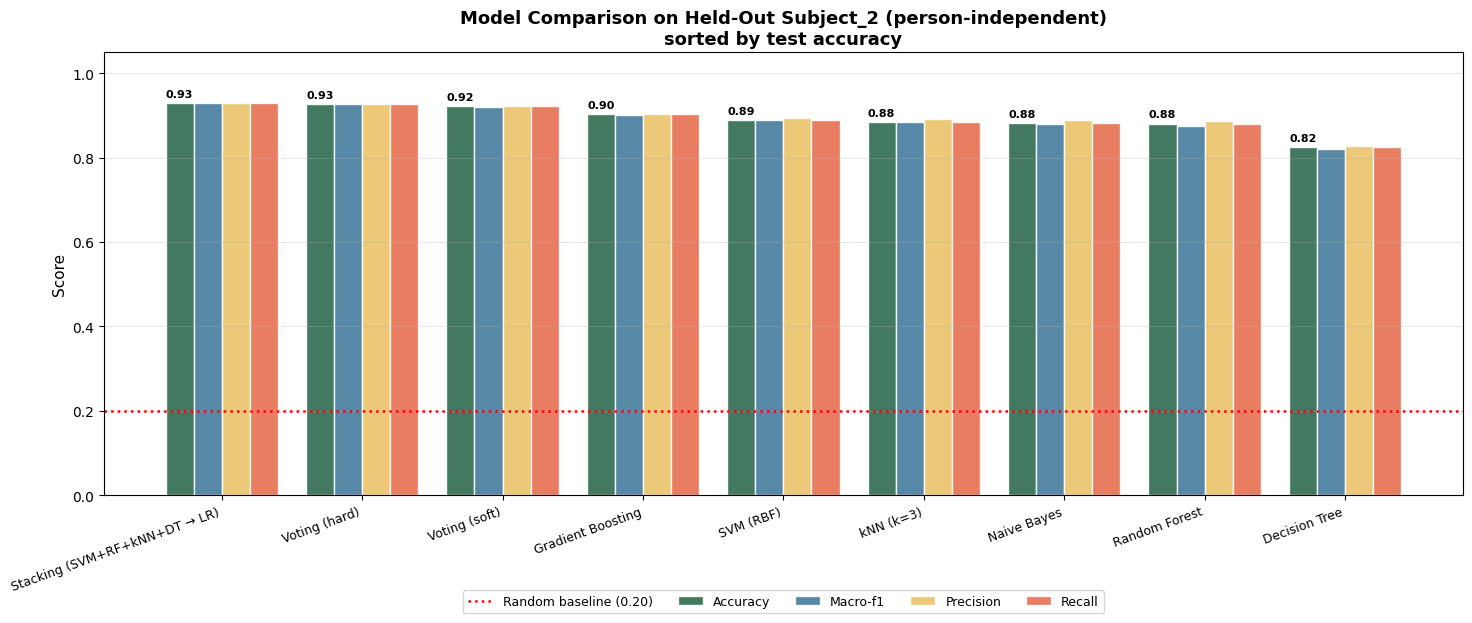

Saved outputs/eda/model_comparison.png


In [13]:
# ── model_comparison.png : acc / macro-F1 / precision / recall, sorted, with
#    a dotted random-baseline line at 0.20 (1/5 classes). ──────────────────────
plot_df = summary.sort_values("Test accuracy", ascending=False).reset_index(drop=True)
metrics = [("Test accuracy", "#2d6a4f"), ("Test macro-F1", "#457b9d"),
           ("Test precision", "#e9c46a"), ("Test recall", "#e76f51")]
x = np.arange(len(plot_df)); width = 0.2

fig, ax = plt.subplots(figsize=(15, 6.5))
for i, (m, c) in enumerate(metrics):
    ax.bar(x + i*width, plot_df[m], width, label=m.replace("Test ", "").capitalize(),
           color=c, alpha=0.9, edgecolor="white")
ax.axhline(0.20, color="red", linestyle=":", linewidth=1.8,
           label="Random baseline (0.20)")
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison on Held-Out Subject_2 (person-independent)\n"
             "sorted by test accuracy", fontweight="bold", fontsize=13)
ax.legend(fontsize=9, ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.28))
ax.grid(axis="y", alpha=0.3)
for j, val in enumerate(plot_df["Test accuracy"]):
    ax.text(j, val + 0.01, f"{val:.2f}", ha="center", va="bottom",
            fontsize=8, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/eda/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/eda/model_comparison.png")

## 11 \u00b7 Best Model \u2014 confusion matrix & per-class report (held-out subject_2)

TRUE BEST model on test subject_2: Stacking (SVM+RF+kNN+DT → LR)
  test accuracy: 0.9295 | test macro-F1: 0.9287
  grouped-CV acc: 0.9920 | CV→test gap: +0.0625

Per-class report (best model):
              precision    recall  f1-score   support

     cooking      0.935     0.830     0.879       224
  exercising      0.886     0.969     0.925       224
        idle      0.991     0.991     0.991       224
     smoking      0.886     0.871     0.878       224
      typing      0.953     0.987     0.969       224

    accuracy                          0.929      1120
   macro avg      0.930     0.929     0.929      1120
weighted avg      0.930     0.929     0.929      1120



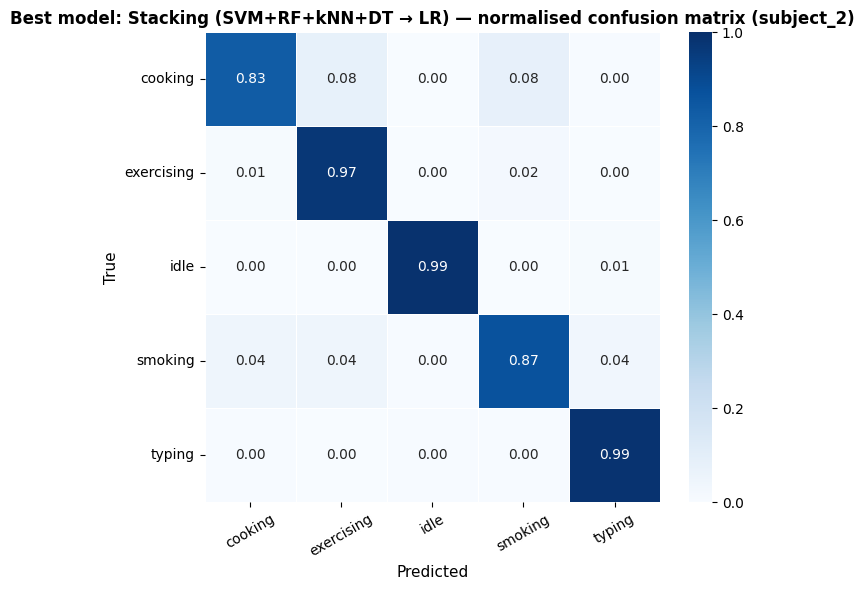

Saved outputs/eda/cm_best.png

Total misclassifications: 79/1120 (7.1%)
Top confusion pairs (true → predicted):
      true       pred  count
   cooking    smoking     19
   cooking exercising     18
   smoking    cooking     10
   smoking exercising     10
   smoking     typing      8
exercising    smoking      5
exercising    cooking      2
      idle     typing      2


In [14]:
best = max(results, key=lambda r: r["f1_macro"])
print(f"TRUE BEST model on test subject_2: {best['model']}")
print(f"  test accuracy: {best['accuracy']:.4f} | test macro-F1: {best['f1_macro']:.4f}")
if best['cv_acc'] is not None:
    print(f"  grouped-CV acc: {best['cv_acc']:.4f} | CV\u2192test gap: "
          f"{best['cv_acc'] - best['accuracy']:+.4f}")

print("\nPer-class report (best model):")
print(classification_report(y_test, best["y_pred"], target_names=CLASS_NAMES, digits=3))

plot_cm(y_test, best["y_pred"], CLASS_NAMES,
        f"Best model: {best['model']} \u2014 normalised confusion matrix (subject_2)",
        path="outputs/eda/cm_best.png")
print("Saved outputs/eda/cm_best.png")

# Main confusions
err = pd.DataFrame({"true":[CLASS_NAMES[i] for i in y_test],
                    "pred":[CLASS_NAMES[i] for i in best["y_pred"]]})
err = err[err.true != err.pred]
print(f"\nTotal misclassifications: {len(err)}/{len(y_test)} "
      f"({100*len(err)/len(y_test):.1f}%)")
print("Top confusion pairs (true \u2192 predicted):")
print(err.groupby(["true","pred"]).size().reset_index(name="count")
         .sort_values("count", ascending=False).head(8).to_string(index=False))

## 12 \u00b7 Save Models & Build results_summary.md

In [15]:
# Save every fitted estimator
name_map = {
    "kNN": "knn", "Decision Tree": "decision_tree", "Random Forest": "random_forest",
    "SVM (RBF)": "svm", "Naive Bayes": "naive_bayes", "Gradient Boosting": "gradient_boosting",
    "Voting (hard)": "voting_hard", "Voting (soft)": "voting_soft", "Stacking": "stacking",
}
for r in results:
    key = next((v for k, v in name_map.items() if r["model"].startswith(k)), r["model"])
    with open(f"outputs/models/{key}.pkl", "wb") as f:
        pickle.dump(r["estimator"], f)
print("Saved fitted models to outputs/models/")
print("Saved outputs/models/model_comparison.csv")

Saved fitted models to outputs/models/
Saved outputs/models/model_comparison.csv


In [16]:
# ── Build the report-writer deliverable: outputs/results_summary.md ──────────
import json as _json

# feature group counts (re-derive from matrix)
TIME_SUF = ["_mean","_std","_min","_max","_range","_rms","_iqr","_skew","_kurt","_mad","_p2p","_zcr","_sma"]
FREQ_SUF = ["_dom_freq","_spec_energy","_spec_entropy","_spec_centroid","_fft_mag_1","_fft_mag_2","_fft_mag_3"]
corr_n = len([c for c in feat_cols if "_corr_" in c])
freq_n = len([c for c in feat_cols if any(c.endswith(s) for s in FREQ_SUF)])
time_n = len(feat_cols) - corr_n - freq_n

grids = {
    "kNN": {"n_neighbors": [1,3,5,7,9,11,15]},
    "Decision Tree": {"max_depth": [3,5,7,10,15,None]},
    "Random Forest": {"n_estimators":[100,200,300],"max_depth":[None,10,20],"max_features":["sqrt",0.3]},
    "SVM (RBF)": {"C":[0.1,1,10,100],"gamma":["scale",0.001,0.01,0.1]},
    "Naive Bayes": "no tuning (GaussianNB defaults)",
    "Gradient Boosting": {"n_estimators":[100,200],"learning_rate":[0.05,0.1],"max_depth":[2,3]},
}
best_params_map = {r["model"]: r["best_params"] for r in results}

# ablation table from feature engineering
abl = pd.read_csv("outputs/features/feature_ablation.csv")
# RF importance top10
fm2 = pd.read_parquet("outputs/features/feature_matrix.parquet")
tr2 = fm2[fm2["subject"].isin(TRAIN_SUBJECTS)]
sc2 = StandardScaler().fit(tr2[feat_cols].values)
rf_imp2 = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_imp2.fit(sc2.transform(tr2[feat_cols].values), le.transform(tr2["label"].values))
top10 = (pd.DataFrame({"feature": feat_cols, "importance": rf_imp2.feature_importances_})
           .sort_values("importance", ascending=False).head(10).reset_index(drop=True))

best = max(results, key=lambda r: r["f1_macro"])
cls_rep = classification_report(y_test, best["y_pred"], target_names=CLASS_NAMES,
                                digits=3, output_dict=True)
err = pd.DataFrame({"true":[CLASS_NAMES[i] for i in y_test],
                    "pred":[CLASS_NAMES[i] for i in best["y_pred"]]})
err = err[err.true != err.pred]
top_conf = (err.groupby(["true","pred"]).size().reset_index(name="count")
              .sort_values("count", ascending=False).head(6))

L = []
L.append("# ML4QS Group 40 \u2014 Results Summary (person-independent)\n")
L.append("Generated from the actual re-run of `modelling.ipynb`. Train = subject_1 + subject_3; "
         "Test = held-out subject_2. 5 balanced classes.\n")

L.append("## Dataset / windowing\n")
L.append(f"- Sampling rate (after resampling): **50 Hz**")
L.append(f"- Window: **2 s, 50% overlap** (1 s step)")
L.append(f"- Windows total: **{len(fm2)}** | train (subj 1+3): **{len(y_train)}** | test (subj 2): **{len(y_test)}**")
L.append(f"- Per activity: 672 total (448 train / 224 test), 5 activities {ACTIVITIES}")
L.append(f"- Feature counts: time **{time_n}** + frequency **{freq_n}** + correlation **{corr_n}** = **{len(feat_cols)}** total\n")

L.append("## Results table (sorted by test macro-F1)\n")
L.append("| Model | Best hyperparameters | Grouped-CV acc | Test acc | Test macro-F1 |")
L.append("|---|---|---|---|---|")
for r in sorted(results, key=lambda r: r["f1_macro"], reverse=True):
    cv = f"{r['cv_acc']:.4f}" if r["cv_acc"] is not None else "-"
    L.append(f"| {r['model']} | {r['best_params']} | {cv} | {r['accuracy']:.4f} | {r['f1_macro']:.4f} |")
L.append("")

L.append("## Hyperparameter grids searched (GridSearchCV under GroupKFold)\n")
for m, g in grids.items():
    bp = best_params_map.get(m) or best_params_map.get(next((k for k in best_params_map if k.startswith(m.split(' ')[0])), m), "-")
    L.append(f"- **{m}** \u2014 grid: `{g}` \u2192 best: `{bp}`")
L.append("")

L.append("## Grouped-CV vs test gap (top models) + LOSO\n")
top_models = sorted([r for r in results if r["cv_acc"] is not None],
                    key=lambda r: r["f1_macro"], reverse=True)[:4]
L.append("| Model | Grouped-CV acc | Test acc | CV\u2192test gap |")
L.append("|---|---|---|---|")
for r in top_models:
    L.append(f"| {r['model']} | {r['cv_acc']:.4f} | {r['accuracy']:.4f} | {r['cv_acc']-r['accuracy']:+.4f} |")
L.append("")
L.append("Leave-one-subject-out (train on one training subject, validate on the other):\n")
for m, a in loso_results.items():
    L.append(f"- **{m}**: LOSO acc = **{a:.4f}**")
L.append("")
gap_best = best["cv_acc"] - best["accuracy"]
L.append(f"**Interpretation:** grouped-CV ({best['cv_acc']:.3f}) and test ({best['accuracy']:.3f}) "
         f"are close (gap {gap_best:+.3f}) for the best model, so grouped-CV is an honest "
         f"predictor of new-recording performance; the lower LOSO number shows the harder "
         f"jump to a genuinely new *person*.\n")

L.append(f"## Best model: {best['model']}\n")
L.append(f"- Test accuracy: **{best['accuracy']:.4f}**, test macro-F1: **{best['f1_macro']:.4f}**\n")
L.append("Per-class precision / recall / F1:\n")
L.append("| Class | Precision | Recall | F1 |")
L.append("|---|---|---|---|")
for c in CLASS_NAMES:
    d = cls_rep[c]
    L.append(f"| {c} | {d['precision']:.3f} | {d['recall']:.3f} | {d['f1-score']:.3f} |")
L.append("")
L.append("Main confusions (true \u2192 predicted):\n")
for _, row in top_conf.iterrows():
    L.append(f"- {row['true']} \u2192 {row['pred']}: {int(row['count'])}")
L.append("")

L.append("## Top 10 features by Random Forest importance\n")
L.append("| Rank | Feature | Importance |")
L.append("|---|---|---|")
for i, row in top10.iterrows():
    L.append(f"| {i+1} | {row['feature']} | {row['importance']:.4f} |")
L.append("")

L.append("## Feature-group ablation (RandomForest, person-independent)\n")
L.append("| Feature set | n_features | Test accuracy | Test macro-F1 |")
L.append("|---|---|---|---|")
for _, row in abl.iterrows():
    L.append(f"| {row['Feature set']} | {int(row['n_features'])} | {row['Test accuracy']:.4f} | {row['Test macro-F1']:.4f} |")
L.append("")

L.append("## Figures (paths)\n")
L.append("- `notebooks/outputs/eda/model_comparison.png` \u2014 all models, 4 metrics, random baseline 0.20")
L.append("- `notebooks/outputs/eda/cm_best.png` \u2014 normalised confusion matrix of the best model")
L.append("- `notebooks/outputs/eda/rf_feature_importance.png` \u2014 top-20 RF feature importances")
L.append("")

out_path = "../outputs/results_summary.md"
Path("../outputs").mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    f.write("\n".join(L))
print(f"Wrote {out_path}")
print("\n".join(L[:40]))

Wrote ../outputs/results_summary.md
# ML4QS Group 40 — Results Summary (person-independent)

Generated from the actual re-run of `modelling.ipynb`. Train = subject_1 + subject_3; Test = held-out subject_2. 5 balanced classes.

## Dataset / windowing

- Sampling rate (after resampling): **50 Hz**
- Window: **2 s, 50% overlap** (1 s step)
- Windows total: **3360** | train (subj 1+3): **2240** | test (subj 2): **1120**
- Per activity: 672 total (448 train / 224 test), 5 activities ['smoking', 'typing', 'idle', 'cooking', 'exercising']
- Feature counts: time **156** + frequency **84** + correlation **9** = **249** total

## Results table (sorted by test macro-F1)

| Model | Best hyperparameters | Grouped-CV acc | Test acc | Test macro-F1 |
|---|---|---|---|---|
| Stacking (SVM+RF+kNN+DT → LR) | bases: tuned SVM+RF+kNN+DT; final: LogReg | 0.9920 | 0.9295 | 0.9287 |
| Voting (hard) | bases: tuned SVM+RF+kNN+DT | 0.9924 | 0.9277 | 0.9271 |
| Voting (soft) | bases: tuned SVM+RF+kNN+DT | 0.9929